In [1]:
import pandas as pd 
import mysql.connector

In [3]:
query = "SELECT * FROM superstore"

df = pd.read_sql(query, connection)

C:\Users\Acer\AppData\Local\Temp\ipykernel_5792\1246816146.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9694 entries, 0 to 9693
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9694 non-null   int64  
 1   Order ID       9694 non-null   object 
 2   Order Date     9694 non-null   object 
 3   Ship Date      9694 non-null   object 
 4   Ship Mode      9694 non-null   object 
 5   Customer ID    9694 non-null   object 
 6   Customer Name  9694 non-null   object 
 7   Segment        9694 non-null   object 
 8   Country        9694 non-null   object 
 9   City           9694 non-null   object 
 10  State          9694 non-null   object 
 11  Postal Code    9694 non-null   int64  
 12  Region         9694 non-null   object 
 13  Product ID     9694 non-null   object 
 14  Category       9694 non-null   object 
 15  Sub-Category   9694 non-null   object 
 16  Product Name   9694 non-null   object 
 17  Sales          9694 non-null   float64
 18  Quantity

In [6]:
df.shape

(9694, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [8]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000,9694.000000
mean,4993.926140,55190.491025,234.418182,3.790902,0.155167,29.178642
std,2885.273358,32050.129070,631.789011,2.227335,0.204867,237.716782
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2496.250000,23223.000000,17.480000,2.000000,0.000000,1.735200
50%,4992.500000,56301.000000,55.928000,3.000000,0.200000,8.730750
75%,7489.750000,90008.000000,214.850000,5.000000,0.200000,30.009300
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [13]:


df["Order Date"].dt.month

0       11
1       11
2        6
3       10
4       10
        ..
9689     1
9690     2
9691     2
9692     2
9693     5
Name: Order Date, Length: 9694, dtype: int32

In [14]:
df["Sales"].sum()

np.float64(2272449.8563)

In [15]:
df["Sales"].mean()

np.float64(234.41818199917475)

In [16]:
df["Sales"].min()

0.444

In [17]:
df.nlargest(10,"Sales")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2616,2698,CA-2014-145317,2014-03-18,2014-03-23,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,32216,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6628,6827,CA-2016-118689,2016-10-02,2016-10-09,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,47905,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
7909,8154,CA-2017-140151,2017-03-23,2017-03-25,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,98115,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2544,2624,CA-2017-127180,2017-10-22,2017-10-24,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,10024,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4067,4191,CA-2017-166709,2017-11-17,2017-11-22,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,19711,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
8768,9040,CA-2016-117121,2016-12-17,2016-12-21,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,48205,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
3980,4099,CA-2014-116904,2014-09-23,2014-09-28,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,55407,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4147,4278,US-2016-107440,2016-04-16,2016-04-20,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,8701,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8232,8489,CA-2016-158841,2016-02-02,2016-02-04,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,22204,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6235,6426,CA-2016-143714,2016-05-23,2016-05-27,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,...,19120,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [18]:
df.groupby("Region")["Sales"].sum()

Region
Central    497800.8728
East       672194.0540
South      388983.5850
West       713471.3445
Name: Sales, dtype: float64

In [19]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          733046.8613
Office Supplies    703502.9280
Technology         835900.0670
Name: Sales, dtype: float64

In [20]:
df.groupby("Discount")["Sales"].max()

Discount
0.00    17499.9500
0.10     3785.2920
0.15     3406.6640
0.20    11199.9680
0.30     4416.1740
0.32     2396.2656
0.40     8399.9760
0.45      957.5775
0.50    22638.4800
0.60      419.6800
0.70     4499.9850
0.80     2177.5840
Name: Sales, dtype: float64

In [21]:
import matplotlib.pyplot as plt


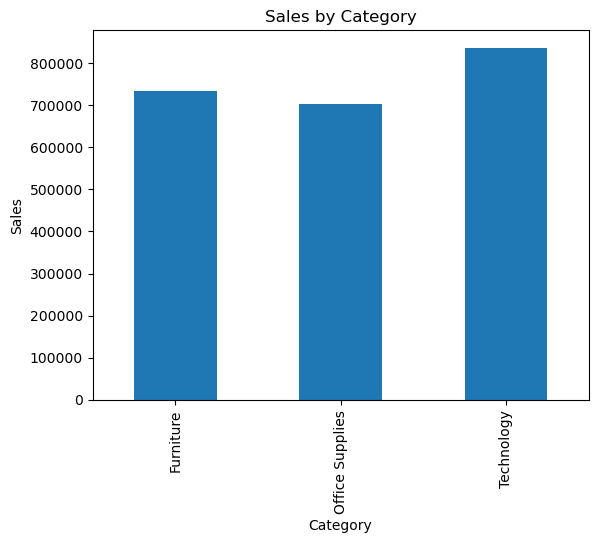

In [22]:
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

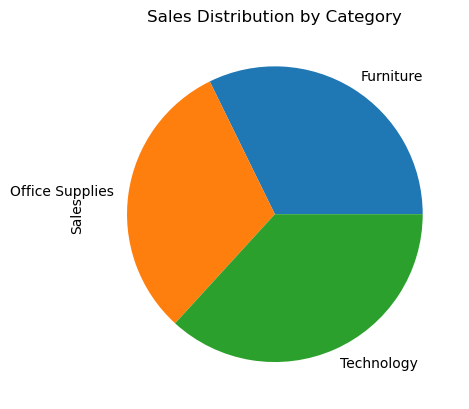

In [23]:
df.groupby("Category")["Sales"].sum().plot(kind="pie")

plt.title("Sales Distribution by Category")

plt.show()

In [24]:
df["Month"] = df["Order Date"].dt.month

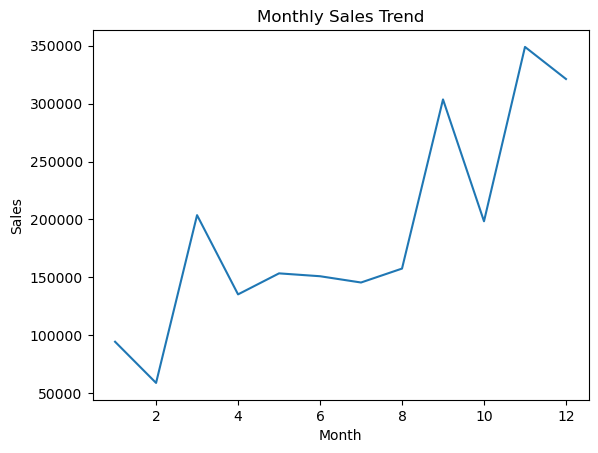

In [25]:
df.groupby("Month")["Sales"].sum().plot(kind="line")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

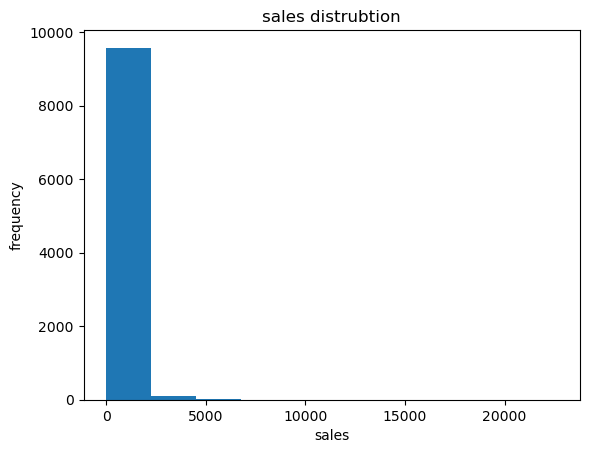

In [26]:
df["Sales"].plot(kind="hist")
plt.title("sales distrubtion")
plt.xlabel("sales")
plt.ylabel("frequency")
plt.show()

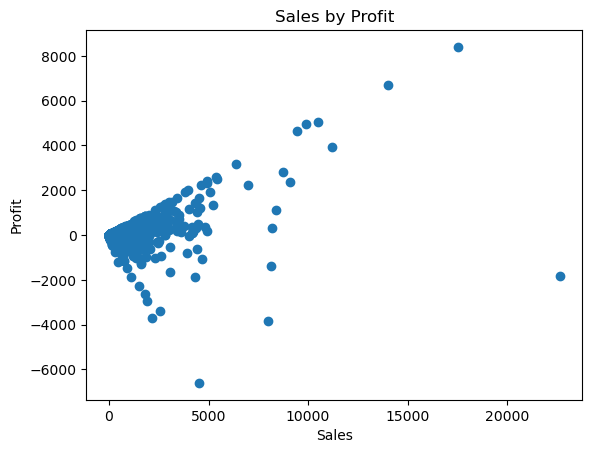

In [27]:
plt.scatter(df["Sales"],df["Profit"])
plt.title("Sales by Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

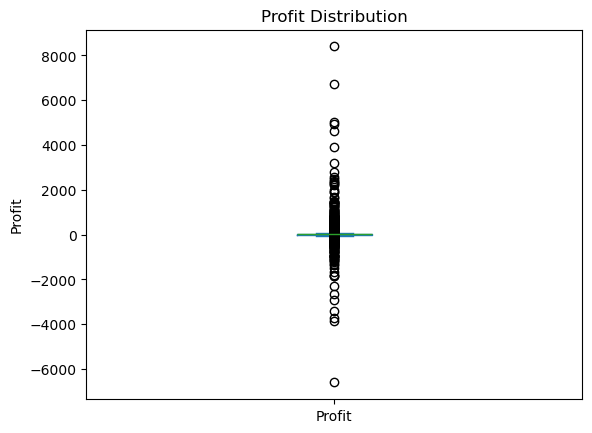

In [28]:
df["Profit"].plot(kind="box")
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

In [29]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Month
Row ID,1.000000,0.011240,-0.001163,-0.003537,0.011074,0.012761,-0.020263
Postal Code,0.011240,1.000000,-0.025184,0.009438,0.064032,-0.030880,0.024702
Sales,-0.001163,-0.025184,1.000000,0.202009,-0.025969,0.479158,-0.000711
Quantity,-0.003537,0.009438,0.202009,1.000000,0.004706,0.066830,0.025069
Discount,0.011074,0.064032,-0.025969,0.004706,1.000000,-0.221510,-0.001437
Profit,0.012761,-0.030880,0.479158,0.066830,-0.221510,1.000000,-0.000572
Month,-0.020263,0.024702,-0.000711,0.025069,-0.001437,-0.000572,1.000000


In [30]:
df.to_csv("superstores_cleaned.csv",index=False)